In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [3]:
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os
from collections import Counter
from sklearn.model_selection import train_test_split

In [5]:
dataset_path = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

In [6]:
import os

# Define your Kaggle dataset root path
dataset_root = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

# Supported image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# Dictionary to hold categories and their nested image paths
category_image_map = {}

# 1. Start scanning the root folder
for entry in os.scandir(dataset_root):
    if entry.is_dir():
        category_name = entry.name
        category_image_map[category_name] = []
        
        # 2. Use os.walk to recursively hunt for images at any depth level
        for root, dirs, files in os.walk(entry.path):
            for file in files:
                if file.lower().endswith(valid_extensions):
                    # 3. Create the absolute path safely
                    full_path = os.path.join(root, file)
                    category_image_map[category_name].append(full_path)

# Quick summary of what we found
for category, paths in category_image_map.items():
    print(f"Category '{category}': Found {len(paths)} nested images.")


Category 'Bridge_Crack_Image': Found 55000 nested images.
Category 'CrackForest': Found 310 nested images.
Category 'Magnetic-Tile-Defect': Found 863 nested images.
Category 'DeepPCB': Found 3021 nested images.


In [7]:
import os
import pandas as pd
from PIL import Image


data_summary = []

for category, paths in category_image_map.items():
    for path in paths:
        try:
            # open() only reads the file header, making it incredibly fast
            with Image.open(path) as img:
                width, height = img.size
                channels = len(img.getbands()) # 3 for RGB, 1 for Grayscale
                
                data_summary.append({
                    'category': category,
                    'file_name': os.path.basename(path),
                    'path': path,
                    'width': width,
                    'height': height,
                    'channels': channels,
                    'aspect_ratio': round(width / height, 2),
                    'status': 'Valid'
                })
        except Exception as e:
            # Catches corrupted images, truncated files, or unreadable formats
            data_summary.append({
                'category': category,
                'file_name': os.path.basename(path),
                'path': path,
                'width': None, 'height': None, 'channels': None, 'aspect_ratio': None,
                'status': f'Corrupted/Error: {str(e)}'
            })

# Convert to DataFrame for quick analysis
df = pd.DataFrame(data_summary)




In [9]:
df.describe

<bound method NDFrame.describe of                  category          file_name  \
0      Bridge_Crack_Image         no335.jpeg   
1      Bridge_Crack_Image      crack323.jpeg   
2      Bridge_Crack_Image        no2497.jpeg   
3      Bridge_Crack_Image      crack750.jpeg   
4      Bridge_Crack_Image        no3111.jpeg   
...                   ...                ...   
59189             DeepPCB  12100001_temp.jpg   
59190             DeepPCB  12100002_temp.jpg   
59191             DeepPCB  12100002_test.jpg   
59192             DeepPCB         eraser.png   
59193             DeepPCB            pen.png   

                                                    path  width  height  \
0      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
1      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
2      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
3      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
4      /kaggle

In [ ]:
for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subdirs: {dirs}")
    print(f"Files: {files}")
    print("\n")

In [14]:
print(dataset_path)
for class_name in os.listdir(dataset_path):
    print(class_name)

/kaggle/input/datasets/yidazhang07/bridge-cracks-image
Bridge_Crack_Image
CrackForest
Magnetic-Tile-Defect
DeepPCB


### current working Directory

In [15]:
import os
print(os.getcwd())
c=os.listdir("/kaggle/working")
print(c)


/kaggle/working
['.virtual_documents']


### Scan Current Folder

In [17]:
for entry in os.scandir('.'):
    print(entry.name, 'File' if entry.is_file() else 'Folder')



.virtual_documents Folder


In [18]:
import os
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")
img_dir_path="/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train"

data = []

for class_name in os.listdir(dataset_path):
    # print(class_name)

    class_folder = os.path.join(dataset_path, class_name)
    # print(class_folder)
    print("\n--- ",class_folder,"\n")

    #inside the Class-folders
    for sub_dir in os.scandir(class_folder):

        
        print(sub_dir)
       
    
    if os.path.isdir(class_folder):

        for img in os.listdir("/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train"):
            # print(os.listdir(class_folder))
            

            if img.lower().endswith(image_extensions):

                data.append({
                    "filepath": os.path.join(class_folder, img),
                    "label": class_name
                })

df = pd.DataFrame(data)


---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image 

<DirEntry 'README.md'>
<DirEntry 'DBCC_quick_train_test.prototxt'>
<DirEntry 'DBCC_Training_Data_Set'>
<DirEntry 'DBCC_quick_solver.prototxt'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/CrackForest 

<DirEntry 'README.md'>
<DirEntry 'groundTruth'>
<DirEntry 'seg'>
<DirEntry 'image'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Magnetic-Tile-Defect 

<DirEntry 'MT_Fray'>
<DirEntry 'MT_Break'>
<DirEntry 'MT_Crack'>
<DirEntry 'MT_Free'>
<DirEntry 'MT_Blowhole'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/DeepPCB 

<DirEntry 'fig'>
<DirEntry 'LICENSE'>
<DirEntry '.gitignore'>
<DirEntry 'PCBData'>
<DirEntry 'README.md'>
<DirEntry 'tools'>
<DirEntry 'evaluation'>


In [20]:
print(df.columns)

Index(['filepath', 'label'], dtype='object')


## DataFrame Information About the dataset

In [21]:
df.describe

<bound method NDFrame.describe of                                                  filepath               label
0       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
4       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
...                                                   ...                 ...
199995  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199996  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199997  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199998  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199999  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB

[200000 rows x 2 columns]>

In [22]:
df.info

<bound method DataFrame.info of                                                  filepath               label
0       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
4       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
...                                                   ...                 ...
199995  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199996  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199997  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199998  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199999  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB

[200000 rows x 2 columns]>

## Totall Numbers of Images Avaible in Dataset

In [23]:
#totall images 
totall_images=len(df)
print(totall_images)

200000


## Numbers of Classes in Dataset

In [24]:
print(df["label"].unique())

['Bridge_Crack_Image' 'CrackForest' 'Magnetic-Tile-Defect' 'DeepPCB']


In [25]:
print(df.head(4))

                                            filepath               label
0  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image


In [26]:
print("Total Classes:", df["label"].nunique())

Total Classes: 4


## Count Images Per Class

In [27]:
class_count=df["label"].value_counts()
print(class_count)

label
Bridge_Crack_Image      50000
CrackForest             50000
Magnetic-Tile-Defect    50000
DeepPCB                 50000
Name: count, dtype: int64


## Percentage of Each Class in Dataset

In [28]:
percentage=df["label"].value_counts(normalize=True)*100
print(percentage)

label
Bridge_Crack_Image      25.0
CrackForest             25.0
Magnetic-Tile-Defect    25.0
DeepPCB                 25.0
Name: proportion, dtype: float64


## Is Dataset is balance or unbalance

In [57]:
check_balance=class_count.max() / class_count.min() 

if check_balance < 1.5:
    print(check_balance)
    print("Dataset is Balanced")
else :
    print(check_balance)
    print("Dataset is Unbalanced")

NameError: name 'class_count' is not defined

## Image Extension

## Split Dataset (73%, 17%, 10%)

In [56]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.27,
    stratify=df["label"],
    random_state=42
)

NameError: name 'train_test_split' is not defined

In [32]:
test_df, val_df = train_test_split(
    temp_df,
    test_size=10/27,
    stratify=temp_df["label"],
    random_state=42
)

In [33]:
print("Training:", len(train_df))
print("Testing :", len(test_df))
print("Validation:", len(val_df))

Training: 146000
Testing : 34000
Validation: 20000


In [34]:
print("Train")
print(train_df["label"].value_counts())

print()

print("Test")
print(test_df["label"].value_counts())

print()

print("Validation")
print(val_df["label"].value_counts())

Train
label
Magnetic-Tile-Defect    36500
Bridge_Crack_Image      36500
CrackForest             36500
DeepPCB                 36500
Name: count, dtype: int64

Test
label
Magnetic-Tile-Defect    8500
DeepPCB                 8500
Bridge_Crack_Image      8500
CrackForest             8500
Name: count, dtype: int64

Validation
label
CrackForest             5000
Bridge_Crack_Image      5000
Magnetic-Tile-Defect    5000
DeepPCB                 5000
Name: count, dtype: int64


In [35]:
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)
val_df.to_csv("validation.csv", index=False)

## Image Dimension 

In [36]:
from PIL import Image
import pandas as pd

sizes = []

for path in df["filepath"]:
    print(path)
    try:
        img = Image.open(path)
        if img:
            print("image is there")
        sizes.append(img.size)
        break
    except:
        print("having issue ")
        break

size_df = pd.DataFrame(sizes, columns=["width","height"])

print(size_df.describe())

/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/no335.jpeg
having issue 
       width height
count      0      0
unique     0      0
top      NaN    NaN
freq     NaN    NaN


### Dimension checking of **Single** image 

In [37]:
path= df["filepath"]
path="/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train/crack10.jpeg"
img=Image.open(path)
size=img.size
height , width = img.size
print(height,width)

16 16


In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

DataDir="/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

root,sub_dir,files=os.walk(DataDir)

for file in files :
    if file.endwith(".jpeg")
    

# Loading Image 
## Weak 2

Found 2 classes



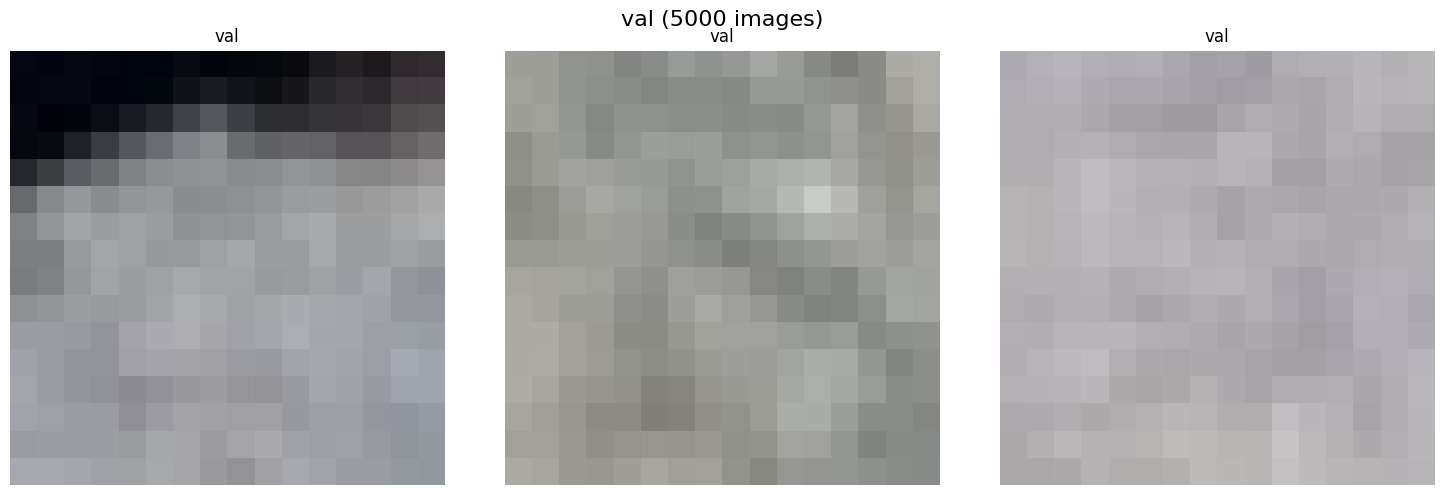

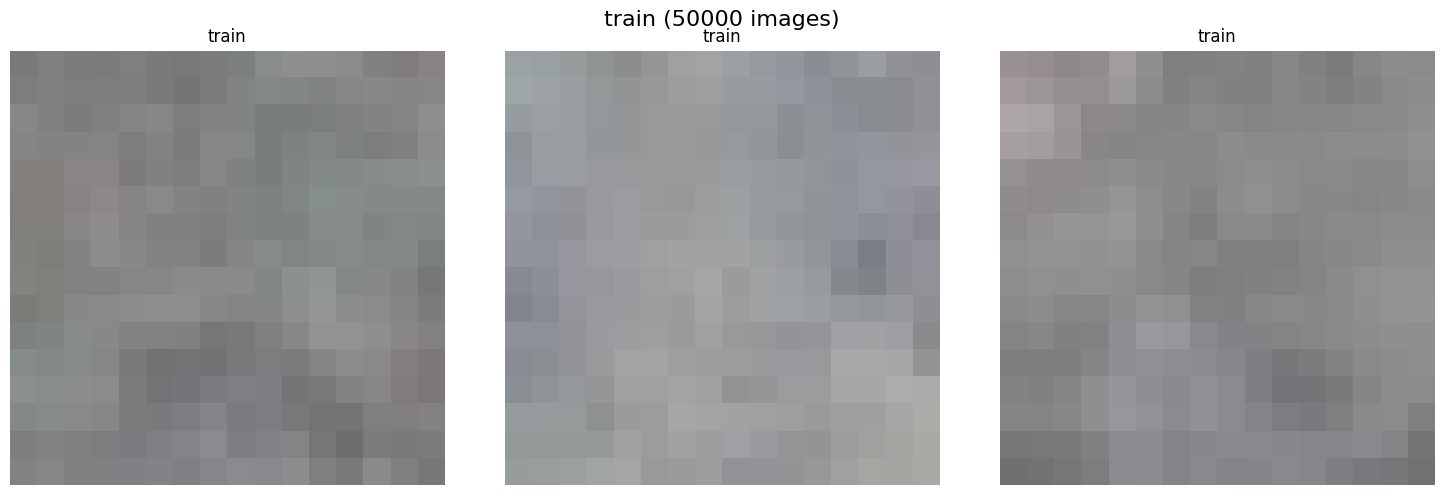

In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Change this to your dataset path
dataset_path = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image"

# Supported image formats
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp')

# Dictionary: {class_name: [image_paths]}
class_images = {}

# Walk through all folders
for root, dirs, files in os.walk(dataset_path):

    # Get image files in current folder
    images = [
        os.path.join(root, f)
        for f in files
        if f.lower().endswith(image_extensions)
    ]

    # If folder contains images, treat it as a class
    if images:
        class_name = os.path.basename(root)
        class_images[class_name] = images

print(f"Found {len(class_images)} classes\n")

# Display 3 images from each class
for class_name, image_list in class_images.items():

    n = min(3, len(image_list))
    samples = random.sample(image_list, n)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)

        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

    plt.suptitle(f"{class_name} ({len(image_list)} images)", fontsize=16)
    plt.tight_layout()
    plt.show()

# Week 3

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [58]:
IMG_SIZE=(32,32)
BATCH_SIZE=32

train_ds=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 55000 files belonging to 2 classes.
Found 55000 files belonging to 2 classes.
Found 55000 files belonging to 2 classes.


In [36]:
normalization=tf.keras.layers.Rescaling(1./255)

train_ds=train_ds.map(lambda x,y:(normalization(x),y))
val_ds=val_ds.map(lambda x,y:(normalization(x),y))


In [40]:
augmentation=tf.keras.Sequential([

    tf.keras.layers.RandomFlip(),

    tf.keras.layers.RandomRotation(0.05),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomContrast(0.1)
])

In [41]:
base=tf.keras.applications.EfficientNetV2B0(

    include_top=False,

    weights="imagenet",

    input_shape=(32,32,3)

)

base.trainable=False

In [42]:
model=tf.keras.Sequential([

    augmentation,

    base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1,activation="sigmoid")

])

In [43]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(),

        tf.keras.metrics.Recall(),

        tf.keras.metrics.AUC()

    ]

)

In [44]:
checkpoint=tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max"

)

In [48]:
early=tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [49]:
reduce=tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3

)

In [50]:
history=model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=30,

    callbacks=[

        checkpoint,

        early,

        reduce

    ]

)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 127s 68ms/step - accuracy: 0.9084 - auc_1: 0.5003 - loss: 0.3097 - precision_1: 0.0833 - recall_1: 8.0000e-04 - val_accuracy: 0.9091 - val_auc_1: 0.5000 - val_loss: 0.3047 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 112s 65ms/step - accuracy: 0.9091 - auc_1: 0.4972 - loss: 0.3084 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9091 - val_auc_1: 0.5000 - val_loss: 0.3046 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 112s 65ms/step - accuracy: 0.9091 - auc_1: 0.5047 - loss: 0.3077 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9091 - val_auc_1: 0.5000 - val_loss: 0.3049 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 112s 65ms/step - accuracy: 0.9091 - auc_1: 0.5012 - loss: 0.3087 

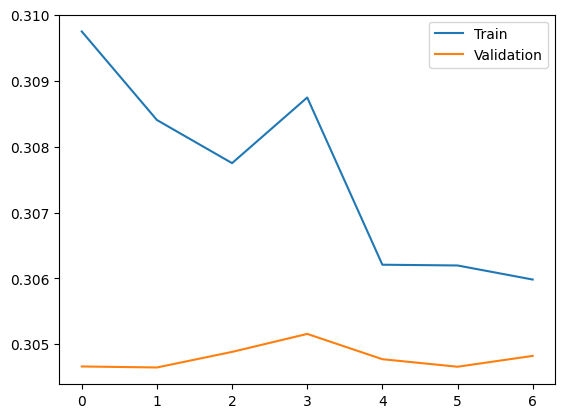

In [51]:
plt.plot(history.history["loss"],label="Train")

plt.plot(history.history["val_loss"],label="Validation")

plt.legend()

plt.show()

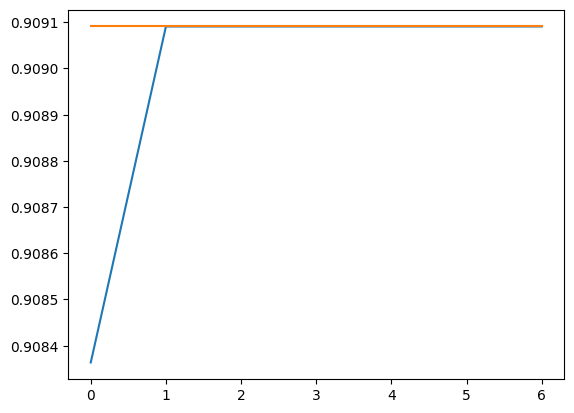

In [52]:
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.show()

In [59]:
pred=model.predict(test_ds)

pred=(pred>0.5).astype(int)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step


In [60]:
y_true=np.concatenate(

    [y for x,y in test_ds],

    axis=0

)

In [61]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_true,pred)

print(cm)

[[50000     0]
 [ 5000     0]]


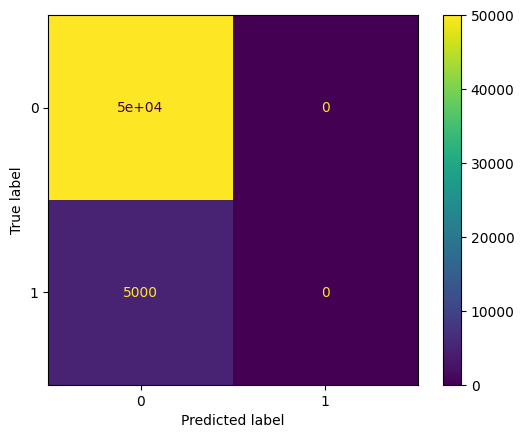

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

disp=ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [63]:
from sklearn.metrics import classification_report

print(

classification_report(

y_true,

pred

)

)

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     50000
           1       0.00      0.00      0.00      5000

    accuracy                           0.91     55000
   macro avg       0.45      0.50      0.48     55000
weighted avg       0.83      0.91      0.87     55000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step


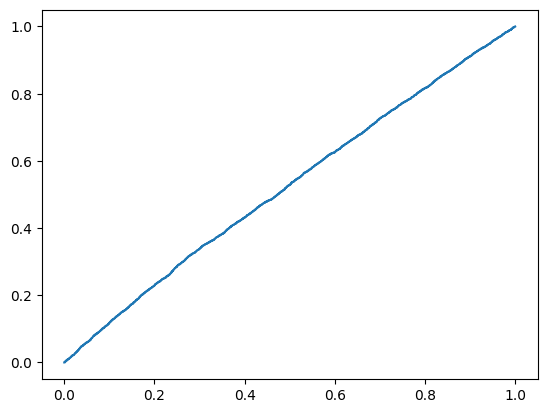

In [64]:
from sklearn.metrics import roc_curve,auc

prob=model.predict(test_ds)

fpr,tpr,_=roc_curve(y_true,prob)

roc_auc=auc(fpr,tpr)

plt.plot(fpr,tpr)

plt.show()

In [73]:
best=tf.keras.models.load_model("best_model.keras")

In [82]:
img=tf.keras.utils.load_img(

"/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/val/crack1000.jpeg",

target_size=(16,16)

)

img=tf.keras.utils.img_to_array(img)

img=np.expand_dims(img,0)/255

prediction=best.predict(img)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.09709091]]
